# Mindestanforderungen 5 - Clustering
- Clusteranalyse durchführen
    - wir haben eine Clusteranalyse auf einen zuvor bereinigten Datensatz mit MiniBatchKMeans durchgeführt
    - Feature-Set waren hierbei eine Kombination aus numerischen und Textspalten.
    - Ziel war es einen groben Überblick über die Entwicklerprofile zu erhalten
- Parameter
    - die Clusteranzahl haben wir über die unüberwachte Evaluationsmethode, mit der Elbow-Methode, gewählt
    - dazu wurden jeweils die Inerita (Sum of Squared Errors) für k von 2-20 berechnet, geplottet und anschließend die passendste Clustergröße gewählt
    - wir haben uns gegen die überwachte Evaluationsmethode entschieden, da wir keine überwachten Metriken haben
    - Silhouetten-Score wurde auf "Empfehlung" von Herrn Speiser nicht betrachtet
- erzeugte Cluster
    - Cluster zeigen sinnvolle Profile
    - Teilweise entstehen Cluster, die stark durch Missingness geprägt sind, kommt durch viele fehlende Werte im Datensatz
- Weiter Nutzung
    - wir wollen die Cluster als "Entwicklerprofile" interpretieren und pro Cluster Kennzahlen oder typische Tools reporten
    - zudem konnten wir bereits durch mehrere Iterationen des Clusterings Outlier erkennen und diese im Cleanup-Notebook ausschließen, da sie klare Datenfehler waren (Gehalt extrem hoch, WorkExp und YearsCode ~100)

Einlesen des Datensatzes, welcher zuvor im `Cleanup`-Notebook vorbereitet wurde

In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix

# -------------------------
# 0) Laden
# -------------------------
df = pd.read_csv("One-Hot-Encoded_new.csv")
print("Loaded:", df.shape)
salary_col = "ConvertedCompTotal"
before = df.shape
df = df.dropna(subset=[salary_col])
df = df[df[salary_col] > 1000]
print(f"Dropped salary NaNs ({salary_col}): {before} -> {df.shape}")

df.to_csv("survey_results_after_clustering.csv", index=False)
print("Saved clustering base:", df.shape, "->", "survey_results_after_clustering.csv")

Loaded: (20603, 386)
Dropped salary NaNs (ConvertedCompTotal): (20603, 386) -> (14687, 386)
Saved clustering base: (14687, 386) -> survey_results_after_clustering.csv


- Alle numerischen Spalten zwischenspeichern
- einzelne Spalten, welche für Clustering nicht benötigt werden oder Cluster verzerren, entfernen (Age wird als String später drin sein)
- durch `num_imputer` werden NaN-Werte spaltenweise durch Median der jeweiligen Spalte ersetzt (nicht immer sinnvoll)
    - wenn NaN gedroppt werden würde, würden wir viele Spalten verlieren, Median ist zudem robust gegen Ausreißer
- `StandardScaler` macht jede numerische Spalte vergleichbar durch z-Score Scaling
    - Scaling wichtig, da sonst Features mit großen Zahlenbereichen alles dominieren würden
    - für KMeans praktisch pflicht, da sonst Distanzen nicht fair

In [3]:
nunique = X_num_raw.nunique(dropna=True)
bin_cols = nunique[(nunique <= 2)].index.tolist()         # 0/1 (ggf. + NaN)
cont_cols = [c for c in num_cols if c not in bin_cols]    # “echte” Numerik

print("Numeric cols total:", len(num_cols))
print("  - bin_cols (0/1):", len(bin_cols))
print("  - cont_cols:", len(cont_cols))

# Continuous: Median-Imputer + StandardScaler (wie bei dir, nur auf cont_cols)
num_imputer = SimpleImputer(strategy="median")
num_scaler = StandardScaler()

X_cont_imp = num_imputer.fit_transform(X_num_raw[cont_cols])
X_cont = num_scaler.fit_transform(X_cont_imp)

# Binary: NaN -> 0 lassen (du hast dummy_na=True, daher sind Missing oft eh als Feature drin)
X_bin = X_num_raw[bin_cols].fillna(0).astype(np.float32).values

# --- Finales Feature-Set: scaled continuous + unscaled binary ---
X_all = hstack([csr_matrix(X_cont), csr_matrix(X_bin)]).tocsr()  # <- .tocsr() (nicht .atocsr)
print("Final X_all shape:", X_all.shape)

Numeric cols total: 92
  - bin_cols (0/1): 85
  - cont_cols: 7
Final X_all shape: (14687, 92)


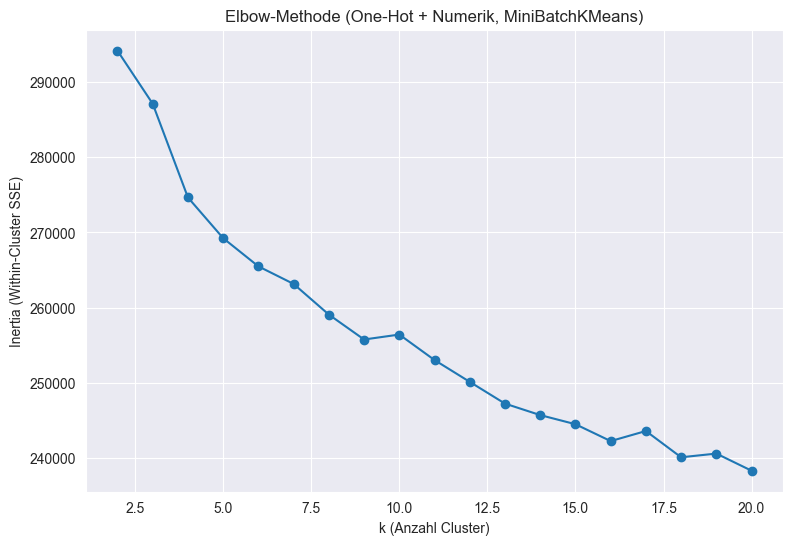

In [4]:
k_values = list(range(2, 21))
inertias = []

for kk in k_values:
    km_tmp = MiniBatchKMeans(n_clusters=kk, random_state=42, batch_size=2048, n_init=10)
    km_tmp.fit(X_all)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(9, 6))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("k (Anzahl Cluster)")
plt.ylabel("Inertia (Within-Cluster SSE)")
plt.title("Elbow-Methode (One-Hot + Numerik, MiniBatchKMeans)")
plt.grid(True)
plt.show()

In [5]:
k = 9
km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048, n_init=10)
labels = km.fit_predict(X_all)

In [6]:
df_out = df.copy()
df_out["cluster"] = labels

sizes = df_out["cluster"].value_counts().sort_index()
summary = pd.DataFrame({
    "n": sizes,
    "pct": (sizes / sizes.sum() * 100).round(2)
})
print("\nClustergrößen:")
print(summary)


Clustergrößen:
            n    pct
cluster             
0        1048   7.14
1        2454  16.71
2        1969  13.41
3        1978  13.47
4         932   6.35
5        1467   9.99
6        1444   9.83
7        1913  13.03
8        1482  10.09


In [7]:
report_num_cols = cont_cols.copy()
if f"{salary_col}_raw" in df_out.columns:
    # wie bei dir: geloggte salary_col nicht reporten, sondern raw
    report_num_cols = [c for c in report_num_cols if c != salary_col] + [f"{salary_col}_raw"]

print("\nNumerik-Mittelwerte pro Cluster (continuous + salary_raw):")
print(df_out.groupby("cluster")[report_num_cols].mean().round(2))


Numerik-Mittelwerte pro Cluster (continuous + salary_raw):
         EdLevel  WorkExp  YearsCode  OrgSize  RemoteCategoryNum  JobSat  \
cluster                                                                    
0           0.67    10.07      14.81     0.54               0.42    2.99   
1           0.76     9.99      14.09     0.61               0.21    7.72   
2           0.74    21.81      27.37     0.52               0.44    7.57   
3           0.72     8.38      12.65     0.47               0.48    7.82   
4           0.63     5.55       8.60     0.38               0.59    6.86   
5           0.44     5.76       9.16     0.30               0.35    7.56   
6           0.47    17.44      21.90     0.38               0.21    7.58   
7           0.72     6.73      11.23     0.58               0.75    7.29   
8           0.66    17.34      22.22     0.51               0.38    7.65   

         ConvertedCompTotal_raw  
cluster                          
0                      83111.58  
1

In [10]:
top_n = 50
bin_means = df_out.groupby("cluster")[bin_cols].mean()

print(f"\nTop {top_n} One-Hot-Features pro Cluster (nach Anteil):")
for cl in range(k):
    top = bin_means.loc[cl].sort_values(ascending=False).head(top_n)
    print(f"\nCluster {cl} (n={int(sizes.get(cl, 0))}):")
    for feat, val in top.items():
        print(f"  {feat}: {val:.3f}")


Top 50 One-Hot-Features pro Cluster (nach Anteil):

Cluster 0 (n=1048):
  PlatformHaveWorkedWith__other: 0.810
  OfficeStackAsyncHaveWorkedWith__github: 0.779
  LanguageHaveWorkedWith__javascript: 0.729
  LanguageHaveWorkedWith__other: 0.720
  DevEnvsHaveWorkedWith__visual studio code: 0.715
  PlatformHaveWorkedWith__docker: 0.683
  LanguageHaveWorkedWith__html/css: 0.658
  LanguageHaveWorkedWith__sql: 0.628
  OfficeStackAsyncHaveWorkedWith__jira: 0.608
  WebframeHaveWorkedWith__other: 0.606
  LanguageHaveWorkedWith__python: 0.574
  PlatformHaveWorkedWith__npm: 0.564
  LanguageHaveWorkedWith__typescript: 0.563
  DatabaseHaveWorkedWith__postgresql: 0.534
  LanguageHaveWorkedWith__bash/shell (all shells): 0.531
  DevEnvsHaveWorkedWith__other: 0.496
  AIModelsHaveWorkedWith__openai gpt (chatbot models): 0.469
  OfficeStackAsyncHaveWorkedWith__other: 0.463
  OfficeStackAsyncHaveWorkedWith__confluence: 0.447
  AIModelsHaveWorkedWith__none: 0.445
  PlatformHaveWorkedWith__amazon web service

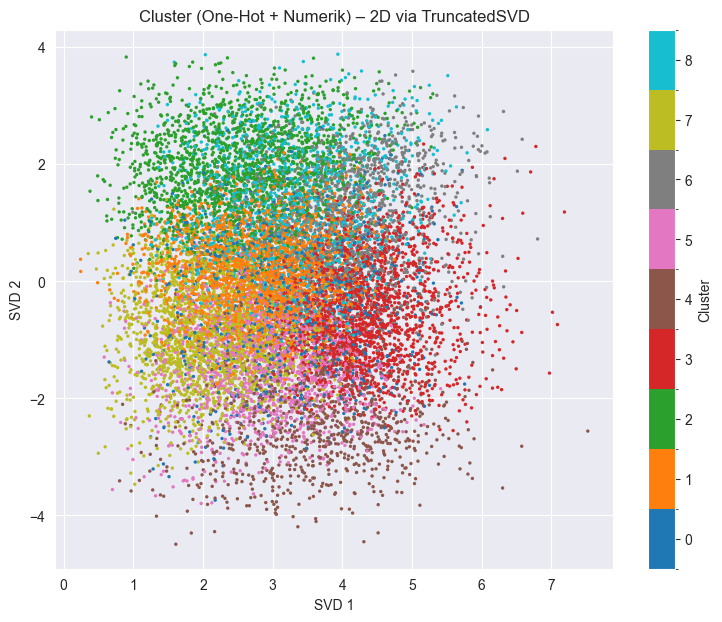

In [15]:
cmap = plt.get_cmap("tab10", k)   # k=9 -> perfekt
norm = BoundaryNorm(np.arange(-0.5, k + 0.5, 1), k)

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_all)

plt.figure(figsize=(9, 7))
sc = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=labels,
    s=6,
         # 👈 weniger “Matsch”
    cmap=cmap,
    norm=norm,
    linewidths=0
)
plt.title("Cluster (One-Hot + Numerik) – 2D via TruncatedSVD")
plt.xlabel("SVD 1")
plt.ylabel("SVD 2")

cbar = plt.colorbar(sc, ticks=range(k))
cbar.set_label("Cluster")

plt.grid(True)
plt.show()

- Zwischenspeichern aller Text-/Kategoriespalten -> für TF-IDF später
- herausfiltern einzelner Spalten, analog numerischer Spalten
    - Country: Demografischer Aspekt weglassen
    - RemoteWork ist als Zahlenskala schon dabei
- erkennen der Multi-Select Spalten anhand des Semikolons (wenn Anteil Semikolons höher der Schwelle -> Multi-Select
    - Multi-Select wird später anders tokenisiert werden, da es zuerst gesplittet werden muss und mehrere Tokens pro Zeile gibt
- Aufteilen der Mulit-Select und Single-Select spalten für späteres Dokument bauen mit dem TF-IDF Vectorizer
- Herausfiltern der Single-Choice Freitext Felder
    - Spalten mit 2-200 verschiedenen Einträgen werden behalten, 200 als grober Richtwert

Multi cols: 10
Single cols: 13


Top-map built for multi-cols: 10


- hier werden aus einzelnen Zeilen Dokumente gebaut für Vectorizer
- `parse_semicolon_list` erzeugt leere Listen, wenn NaN-Werte vorhanden sind, ansonsten splitten nach Semikolon und alles lowercase machen für besseres Handling
- `normalize_token` ersezte Leerzeichen mit Unterstrichen und setzt den token auf lowercase
    - dadurch wird verhindert, dass aus bspw. `visual studio code` nicht als drei getrennte Tokens erkannt werden
- bei `row_to_doc` werden dann pro person bzw. Zeile eine Liste von Tokens erzeugt
    - am Ende aus allen Tokens ein großer String im Stil `Spalte_Wert`
    - NaN-Werte werden geskippt, da uns eigentlich ja nur ausgefüllt Werte interessieren
- Warum das Ganze?
    - der TFIDF-Vectorizer erwartet eine Liste an Dokumenten, weshalb wir für jede Zeile/Person ein Dokument bauen

- hier werden aus den zuvor erzeugten Dokumenten eine numerische Feature-Matrix erstellt, um später alles zusammenzuwerfen und zu clustern
- TFIDF-Vectorizer
    - macht Matrix aus Spalte_Wert:
        - Zeilen/Dokumente = Personen
        - Spalten = Tokens
        - Werte = TFIDF-Gewichte, also wie "typisch" der Token für die Person ist
    - Tokens sind durch Leerzeichen getrennt, deshalb `str.split`
    - `token_pattern = None`, weil Vectorizer sonst sein eigenes Tokenizing erzwingen würde
    - `lowercase=False`, wurde vorher schon erledigt, wäre hier redundant
    - *minimum document frequency* -> ein Token muss in mindestens 50 Personen vorkommen, sonst fliegt er raus
        - so können extrem seltene Tokens rausgeworfen werden, die eher Nischen widerspiegeln
    - *max features*, begrenzt Anzahl der Tokenspalten auf 10.000
    - `fit_transform` baut Vokabular aus Tokens und erstellt Sparse Matrix der TFIDF Werte

TF-IDF shape: (14687, 209)


- Zusammenfügen der Numerischen und Textuellen Features zu gemeinsamen Feature Set für Clustering
- `X_num` kommt vom StandardScaler der numerischen Werte
- `X_text` kommt aus dem TFIDF Vectorizer
- `hstack` = horizontal stack -> Features nebeneinander
    - so sind weiterhin gleiche Anzahl an Zeilen/Personen
    - aber Spalten sind nun Numerische Features und TFIDF-Tokens
- `.tocsr()` konvertiert resultierende Matix explizit in CSR Format (Compressed Row Sotrage)
    - *The CSR format is optimized for fast row slicing and matrix-vector products. It compresses the sparse matrix by storing only the non-zero elements and the corresponding row indices. The structure is divided into three one-dimensional arrays*

Final X_all shape: (14687, 215)


- Anzahl Cluster von 2-20 testen
- `inertias` sammelt die jeweilige Inertias Qualität für das k
- `MiniBatchKMeans` ist eine Variante von KMeans, welche schneller bei großen/hohen Dimensionen ist, weil sie eben in Minibatches arbeitet
    - sinnvoll, da unser Datensatz groß ist
- `km_tmp.inertia_` summiert die quadrierten Abstände aller Punkte, somit können wir in dem Graphen den Elbow suchen und anschließend das beste *k* auswählen

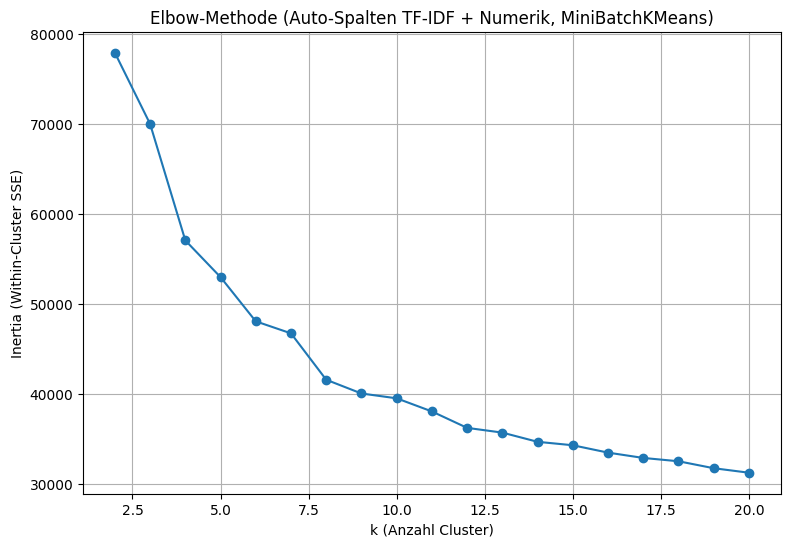

In [14]:
k_values = list(range(2, 21))
inertias = []

for kk in k_values:
    km_tmp = MiniBatchKMeans(n_clusters=kk, random_state=42, batch_size=2048, n_init=10)
    km_tmp.fit(X_all)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(9, 6))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("k (Anzahl Cluster)")
plt.ylabel("Inertia (Within-Cluster SSE)")
plt.title("Elbow-Methode (Auto-Spalten TF-IDF + Numerik, MiniBatchKMeans)")
plt.grid(True)
plt.show()

- aus Elbowplot wurde k=7 am besten empfunden
- Silhouette weggelassen aufgrund Empfelung von Hr. Speiser
- anschließend Clustering-Modell erstellen mit denselben Parametern wie zuvor
- `fit.predict` durch das *fit* "lernt" das Modell die 7 Clusterzentren auf Basis der zuvor erstellten Feature-Matrix`X_all`, *predict* weißt anschließend jede Zeile/Person einem Cluster zu

In [15]:
k = 7  # <- nach Elbow wählen
km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048, n_init=10)
labels = km.fit_predict(X_all)

- hier werden interpretierbare Cluster erstellt
- Wir erhalten die:
    - Clustergrößen
    - Numerik-Mittelwerte
    - Cluster-Zentren
    - Top IFIDF Tokens pro Cluster
    - Top Kategorien


In [16]:
df_out = df.copy()
df_out["cluster"] = labels

# A) Clustergrößen + Prozent
sizes = df_out["cluster"].value_counts().sort_index()
summary = pd.DataFrame({
    "n": sizes,
    "pct": (sizes / sizes.sum() * 100).round(2)
})
print("\nClustergrößen:")
print(summary)

report_num_cols = num_cols.copy()
if f"{salary_col}_raw" in df_out.columns and salary_col in report_num_cols:
    report_num_cols = [c for c in report_num_cols if c != salary_col] + [f"{salary_col}_raw"]

# B) Numerik-Mittelwerte pro Cluster (Original-Skala)
print("\nNumerik-Mittelwerte pro Cluster (Original-Skala):")
print(df_out.groupby("cluster")[report_num_cols].mean().round(2))

# C) Numerik-Zentren (aus KMeans-Zentren zurücktransformiert)
centers_scaled_num = km.cluster_centers_[:, :len(num_cols)]
centers_num = num_scaler.inverse_transform(centers_scaled_num)
centers_num = pd.DataFrame(centers_num, columns=num_cols)
centers_num.index.name = "cluster"

if salary_col in centers_num.columns:
    centers_num[salary_col] = np.expm1(centers_num[salary_col])

print("\nCluster-Zentren (Numerik, Original-Skala):")
print(centers_num.round(2))

# D) Top TF-IDF Tokens pro Cluster
terms = vectorizer.get_feature_names_out()
centers_text = km.cluster_centers_[:, len(num_cols):]

top_n = 12
print("\nTop TF-IDF Tokens pro Cluster:")
for cl in range(km.n_clusters):
    top_idx = np.argsort(centers_text[cl])[::-1][:top_n]
    print(f"\nCluster {cl} (n={int(sizes.get(cl, 0))}):")
    for j in top_idx:
        print(f"  {terms[j]}  ({centers_text[cl][j]:.4f})")

# E) Optional: Top-Kategorien pro Cluster (nur falls vorhanden)
cat_check = ["Employment", "MainBranch", "RemoteWork", "Industry"]
for col in cat_check:
    if col in df_out.columns:
        print(f"\nTop {col} pro Cluster (Anteil):")
        tmp = (df_out.groupby("cluster")[col]
               .value_counts(normalize=True)
               .rename("share")
               .reset_index()
               .sort_values(["cluster", "share"], ascending=[True, False])
               .groupby("cluster")
               .head(3))
        print(tmp)


Clustergrößen:
            n    pct
cluster             
0        1562  10.64
1        2196  14.95
2        4126  28.09
3         617   4.20
4        2405  16.38
5         761   5.18
6        3020  20.56

Numerik-Mittelwerte pro Cluster (Original-Skala):
         WorkExp  YearsCode  RemoteCategoryNum  JobSat  RemoteMissing  \
cluster                                                                 
0           5.39       8.71               0.29    6.94            0.0   
1          18.69      24.15               0.73    7.29            0.0   
2           9.02      13.01               0.16    7.37            0.0   
3          20.58      25.73               0.50    7.53            1.0   
4          20.25      25.30               0.09    7.38            0.0   
5           8.59      11.78               0.50    6.87            1.0   
6           5.72      10.10               0.83    6.83            0.0   

         ConvertedCompTotal_raw  
cluster                          
0                 

**Nur für Visualisierung**
- Dimensions-Reduktion, die sehr hochdimensionale Matrix auf 2 Komponenten herunterbricht
- TruncatedSVD funktioniert gut für sparse Matrizen, PCA zetriert meist und braucht dense Matrizen
- zeichnet jeden Datenpunkt als Punkt im 2D-Raum eingefärbt nach Cluster

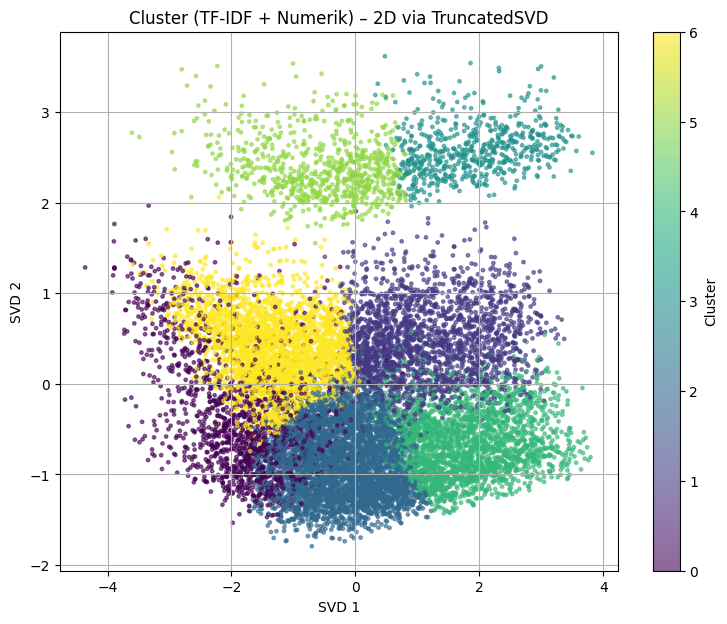

In [17]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_all)

plt.figure(figsize=(9, 7))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=6, alpha=0.6)
plt.title("Cluster (TF-IDF + Numerik) – 2D via TruncatedSVD")
plt.xlabel("SVD 1")
plt.ylabel("SVD 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()


In [18]:
df_out.loc[df_out.cluster==3, "ConvertedCompTotal"].describe()

count       617.000000
mean     110210.938250
std       51621.931004
min        1871.864331
25%       71954.059816
50%      104000.000000
75%      144400.000000
max      235000.000000
Name: ConvertedCompTotal, dtype: float64